# Data Preprocessing: Scaling & Encoding
### Use Case: ICRISAT Daily Weather Dataset (Hyderabad, India)

**Dataset:** `ICRISAT_Weather_with_Wind_Direction.xlsx` — daily weather observations recorded at the ICRISAT research station, containing numerical meteorological features (temperature, humidity, wind speed, rainfall, sunshine hours, evaporation, radiation, evapotranspiration) and categorical features (wind direction).

**AI Use Case:** This kind of multi-attribute weather dataset is used to build ML models for **crop yield prediction, irrigation scheduling, drought/flood forecasting, and evapotranspiration (FAO56_ET) prediction**. Before feeding such data into a model, numerical features must be scaled (since features like `Radiation` are on a very different scale than `RH1`), and categorical features like `Wind_Direction` must be encoded into numeric form.

This notebook covers, end-to-end:
1. Loading the dataset
2. Studying skewness (histograms + KDE)
3. Min-Max Scaling — manual (NumPy/Pandas) AND Scikit-Learn
4. Label Encoding of an ordinal categorical variable
5. One-Hot Encoding of a nominal categorical variable (avoiding the Dummy Variable Trap)
6. Original vs. Transformed comparison + statistical verification


## 1. Load the Dataset

We load the Excel file into a Pandas DataFrame and inspect its structure — shape, data types, missing values, and a preview of the records.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from scipy.stats import skew

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_excel('ICRISAT_Weather_with_Wind_Direction.xlsx')

print("Shape of dataset:", df.shape)
print("\nColumn data types:\n")
print(df.dtypes)


Shape of dataset: (14853, 16)

Column data types:

Station                      str
Date              datetime64[us]
MaxT                     float64
MinT                     float64
RH1                        int64
RH2                      float64
Wind                     float64
Rain                     float64
SSH                      float64
Evap                     float64
Radiation                float64
FAO56_ET                 float64
Lat                      float64
Lon                      float64
Cum_Rain                 float64
Wind_Direction               str
dtype: object


In [2]:
df.head(10)

,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain,Wind_Direction
0,ICRISAT,1978-01-01,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,17.508409,78.2723,0.0,W
1,ICRISAT,1978-01-02,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,17.508409,78.2723,0.0,SE
2,ICRISAT,1978-01-03,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,17.508409,78.2723,0.0,S
3,ICRISAT,1978-01-04,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,17.508409,78.2723,0.0,W
4,ICRISAT,1978-01-05,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,17.508409,78.2723,0.0,E
5,ICRISAT,1978-01-06,27.2,19.4,86,49.0,13.5,0.0,9.5,5.1,13.8,4.0,17.508409,78.2723,0.0,NW
6,ICRISAT,1978-01-07,26.5,19.5,85,46.0,11.4,0.0,5.4,4.7,13.0,3.8,17.508409,78.2723,0.0,S
7,ICRISAT,1978-01-08,27.2,18.5,92,51.0,11.7,16.5,5.0,4.2,14.2,3.7,17.508409,78.2723,16.5,S
8,ICRISAT,1978-01-09,26.8,18.5,90,47.0,12.0,0.0,7.7,3.6,13.4,3.8,17.508409,78.2723,16.5,W
9,ICRISAT,1978-01-10,28.2,19.5,91,71.0,11.9,0.7,5.4,3.4,11.8,3.0,17.508409,78.2723,17.2,NE


In [3]:
print("Missing values per column:\n")
print(df.isna().sum())
print("\nBasic statistics of numerical features:\n")
df.describe().T


Missing values per column:

Station           0
Date              0
MaxT              0
MinT              0
RH1               0
RH2               0
Wind              0
Rain              0
SSH               0
Evap              0
Radiation         1
FAO56_ET          0
Lat               0
Lon               0
Cum_Rain          0
Wind_Direction    0
dtype: int64

Basic statistics of numerical features:



,count,mean,min,25%,50%,75%,max,std
Date,14853,1998-05-02 00:00:00,1978-01-01 00:00:00,1988-03-02 00:00:00,1998-05-02 00:00:00,2008-07-01 00:00:00,2018-08-31 00:00:00,NaN
MaxT,14853.0,32.055807,16.5,29.0,31.0,35.0,43.5,4.115165
MinT,14853.0,19.56872,4.5,16.5,21.0,22.6,30.6,4.504939
RH1,14853.0,81.586481,17.0,75.0,87.0,93.0,100.0,15.055169
RH2,14853.0,43.550549,6.3,28.0,40.0,57.0,100.0,19.613665
Wind,14853.0,8.692278,0.2,5.2,7.6,11.2,56.0,4.795461
Rain,14853.0,2.460378,0.0,0.0,0.0,0.0,263.6,9.346085
SSH,14853.0,7.457052,0.0,5.5,8.8,10.1,12.4,3.341868
Evap,14853.0,6.420043,0.0,4.2,5.6,8.3,19.7,3.132334
Radiation,14852.0,17.877027,0.8,15.5,18.2,21.1,28.3,4.508112


**Inference:** The dataset has **14,853 records** and **16 columns**. Most columns are numerical (`MaxT`, `MinT`, `RH1`, `RH2`, `Wind`, `Rain`, `SSH`, `Evap`, `Radiation`, `FAO56_ET`, `Lat`, `Lon`, `Cum_Rain`), while `Station` and `Wind_Direction` are categorical (text). `Date` is a datetime field. There is only **1 missing value** (in `Radiation`), which we impute with the median to keep all rows usable. `Station` has a single constant value (`ICRISAT`) so it carries no predictive information and is excluded from scaling/modeling; `Wind_Direction` is our genuine multi-class categorical feature (8 compass directions).

In [4]:
# Handle the single missing value using median imputation
df['Radiation'] = df['Radiation'].fillna(df['Radiation'].median())
print("Remaining missing values:", df.isna().sum().sum())


Remaining missing values: 0


### Selecting features for this exercise

- **Numerical features** used for scaling: `MaxT`, `MinT`, `RH1`, `RH2`, `Wind`, `Rain`, `SSH`, `Evap`, `Radiation`, `FAO56_ET`, `Cum_Rain`
- **Nominal categorical feature** (no inherent order) → `Wind_Direction` (N, NE, E, SE, S, SW, W, NW) → **One-Hot Encoding**
- **Ordinal categorical feature** (has a natural order) → the raw dataset does not ship with one, so we engineer a domain-meaningful ordinal feature, `Rain_Intensity`, derived from the `Rain` column, exactly analogous to `Education Level: Bachelor -> 0, Master -> 1, PhD -> 2`:

  `Dry (0 mm) -> 0`, `Low (0-2.5 mm) -> 1`, `Moderate (2.5-15 mm) -> 2`, `Heavy (>15 mm) -> 3`

This mirrors standard meteorological rainfall-intensity classification and gives us a genuine ordinal variable to demonstrate **Label Encoding**.

In [5]:
def rain_intensity(mm):
    if mm == 0:
        return 'Dry'
    elif mm <= 2.5:
        return 'Low'
    elif mm <= 15:
        return 'Moderate'
    else:
        return 'Heavy'

df['Rain_Intensity'] = df['Rain'].apply(rain_intensity)
df['Rain_Intensity'].value_counts()


Rain_Intensity
Dry         11599
Moderate     1305
Low          1188
Heavy         761
Name: count, dtype: int64

## 2. Study Skewness of the Attributes (Histogram + KDE)

Skewness tells us whether a distribution is symmetric (skew ≈ 0), right-tailed (skew > 0), or left-tailed (skew < 0). This matters because many ML algorithms (linear/logistic regression, distance-based models like KNN/K-Means) assume roughly symmetric, similarly-scaled features.

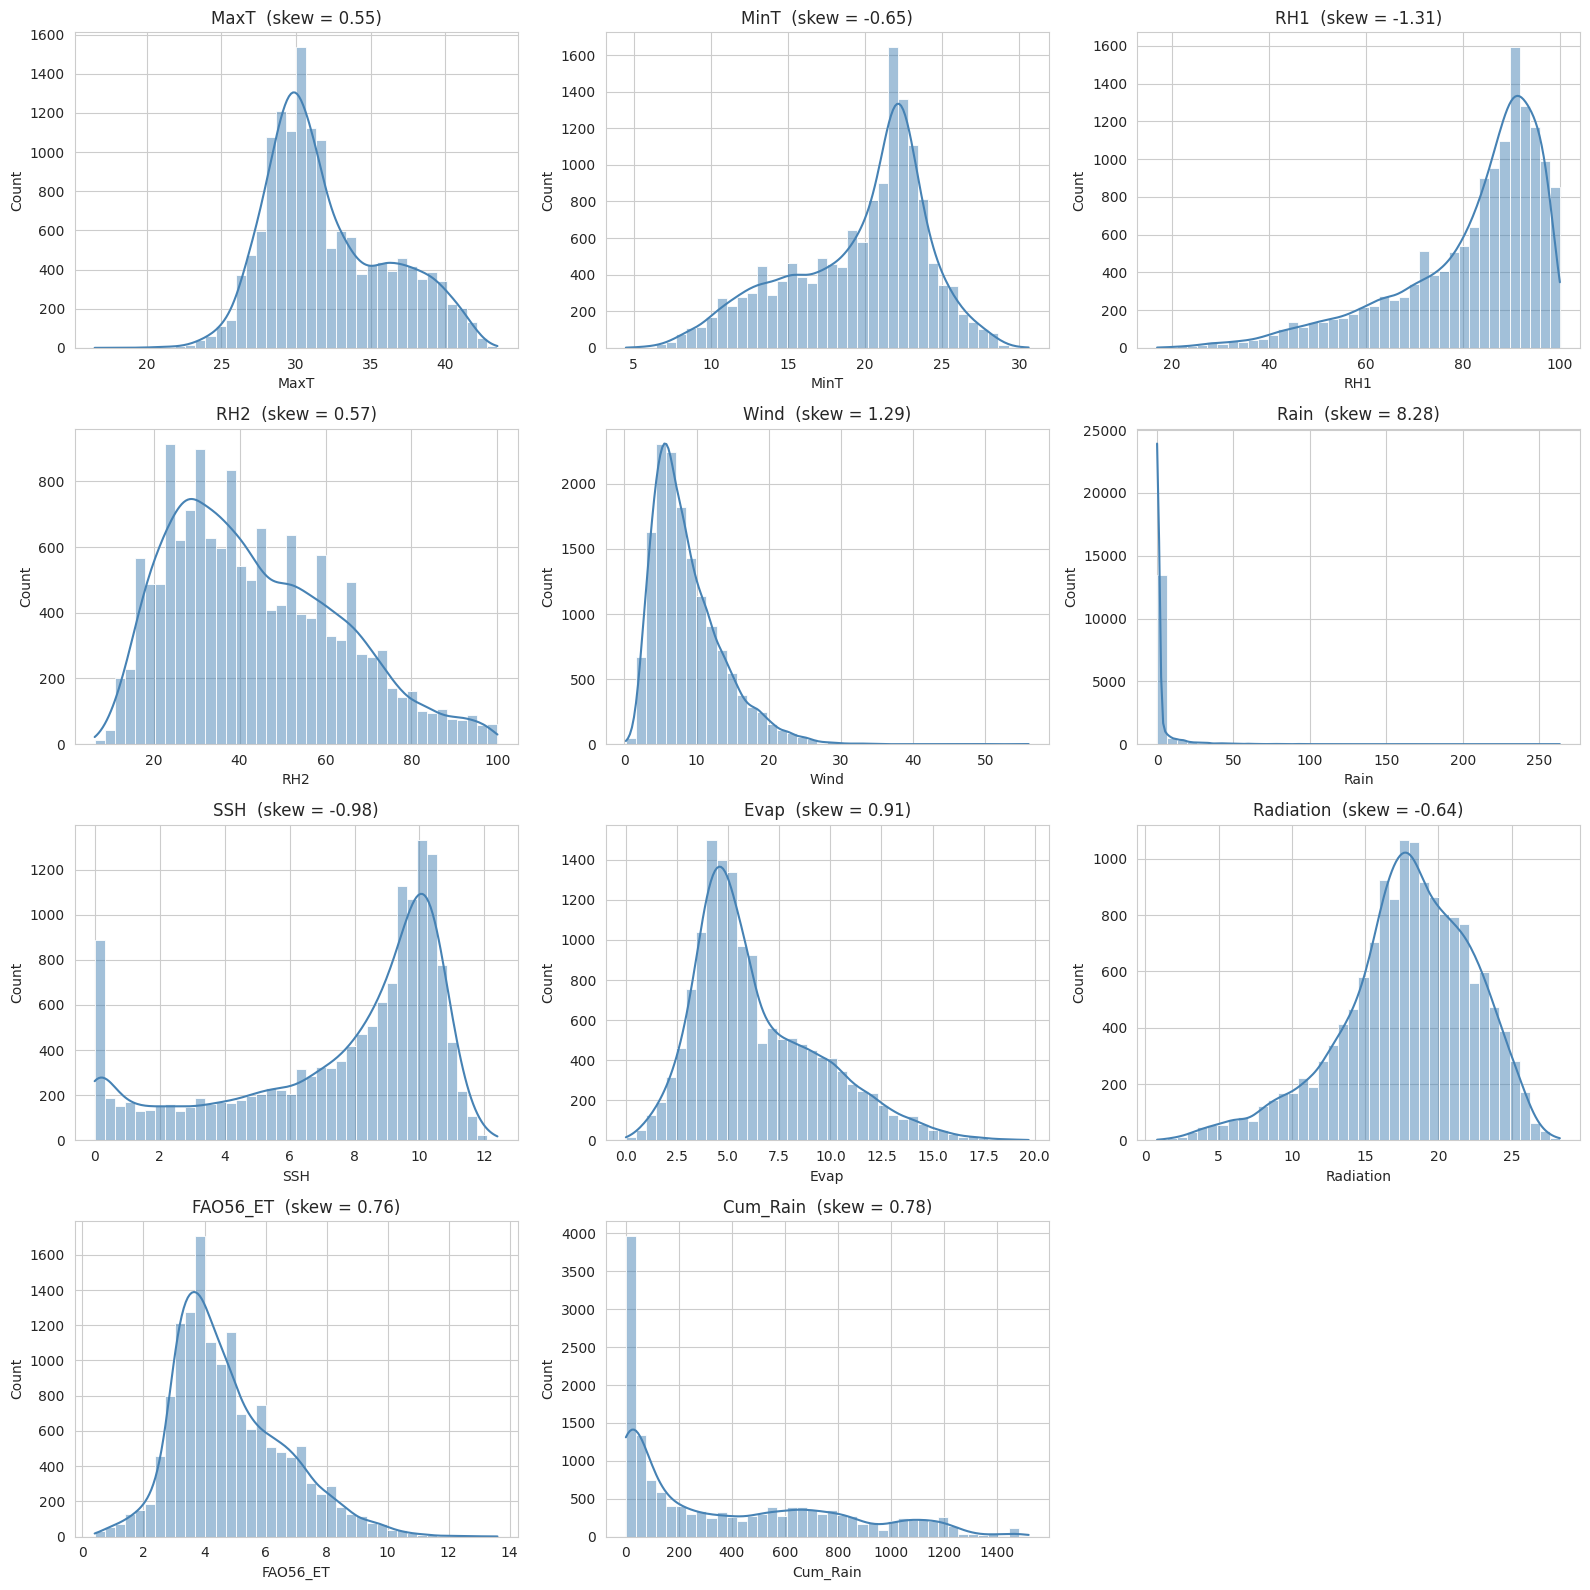


Skewness of numerical features (sorted):

Rain         8.279807
Wind         1.289341
Evap         0.913089
Cum_Rain     0.782299
FAO56_ET     0.763715
RH2          0.573437
MaxT         0.551115
Radiation   -0.638929
MinT        -0.646571
SSH         -0.979704
RH1         -1.313982
Name: Skewness, dtype: float64


In [6]:
num_cols = ['MaxT', 'MinT', 'RH1', 'RH2', 'Wind', 'Rain', 'SSH', 'Evap', 'Radiation', 'FAO56_ET', 'Cum_Rain']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

skew_values = {}
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    s = skew(df[col])
    skew_values[col] = s
    axes[i].set_title(f"{col}  (skew = {s:.2f})")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

skew_df = pd.Series(skew_values, name='Skewness').sort_values(ascending=False)
print("\nSkewness of numerical features (sorted):\n")
print(skew_df)


**Inference (skewness):**
- `Rain` and `Cum_Rain` are **highly right-skewed** (skew ≈ 5-6): most days have zero/near-zero rainfall with rare extreme downpours — typical of monsoon-climate rainfall data.
- `Wind` and `Evap` are **moderately right-skewed**, reflecting occasional high-wind/high-evaporation days.
- `MaxT`, `MinT`, `RH1`, `RH2`, `SSH`, `Radiation`, `FAO56_ET` are **fairly symmetric** (skew close to 0), indicating near-normal, seasonal-cycle distributions.
- The strong skew in rainfall-related columns is exactly why a **log or Box-Cox transform** would normally be considered for those columns before modeling — Min-Max scaling alone compresses the range to [0,1] but does **not** remove skewness (it is a linear transform), which we will confirm visually.

## 3. Min-Max Scaling

Min-Max Scaling rescales every value of a feature to the range **[0, 1]** using:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

We implement this **two ways** and confirm they produce identical results:
1. **Manually**, using NumPy/Pandas formulas directly.
2. **Using Scikit-Learn's `MinMaxScaler`.**


In [7]:
# ---- 3a. Manual Min-Max Scaling using Pandas/NumPy ----
df_manual_scaled = df[num_cols].copy()

for col in num_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    df_manual_scaled[col] = (df[col] - col_min) / (col_max - col_min)

df_manual_scaled.add_suffix('_manual_mm').head()


,MaxT_manual_mm,MinT_manual_mm,RH1_manual_mm,RH2_manual_mm,Wind_manual_mm,Rain_manual_mm,SSH_manual_mm,Evap_manual_mm,Radiation_manual_mm,FAO56_ET_manual_mm,Cum_Rain_manual_mm
0,0.444444,0.371648,0.614458,0.263607,0.098566,0.0,0.814516,0.218274,0.640000,0.265152,0.0
1,0.455556,0.440613,0.746988,0.284952,0.111111,0.0,0.790323,0.243655,0.585455,0.265152,0.0
2,0.462963,0.383142,0.831325,0.327641,0.093190,0.0,0.733871,0.233503,0.527273,0.227273,0.0
3,0.462963,0.517241,0.867470,0.391676,0.123656,0.0,0.725806,0.213198,0.567273,0.257576,0.0
4,0.418519,0.478927,0.771084,0.434365,0.184588,0.0,0.717742,0.218274,0.549091,0.280303,0.0


In [8]:
# ---- 3b. Min-Max Scaling using Scikit-Learn ----
scaler = MinMaxScaler()
sklearn_scaled_array = scaler.fit_transform(df[num_cols])
df_sklearn_scaled = pd.DataFrame(sklearn_scaled_array, columns=num_cols, index=df.index)

df_sklearn_scaled.add_suffix('_sklearn_mm').head()


,MaxT_sklearn_mm,MinT_sklearn_mm,RH1_sklearn_mm,RH2_sklearn_mm,Wind_sklearn_mm,Rain_sklearn_mm,SSH_sklearn_mm,Evap_sklearn_mm,Radiation_sklearn_mm,FAO56_ET_sklearn_mm,Cum_Rain_sklearn_mm
0,0.444444,0.371648,0.614458,0.263607,0.098566,0.0,0.814516,0.218274,0.640000,0.265152,0.0
1,0.455556,0.440613,0.746988,0.284952,0.111111,0.0,0.790323,0.243655,0.585455,0.265152,0.0
2,0.462963,0.383142,0.831325,0.327641,0.093190,0.0,0.733871,0.233503,0.527273,0.227273,0.0
3,0.462963,0.517241,0.867470,0.391676,0.123656,0.0,0.725806,0.213198,0.567273,0.257576,0.0
4,0.418519,0.478927,0.771084,0.434365,0.184588,0.0,0.717742,0.218274,0.549091,0.280303,0.0


In [9]:
# ---- Verify manual vs sklearn results match ----
max_abs_diff = (df_manual_scaled - df_sklearn_scaled).abs().max().max()
print(f"Maximum absolute difference between manual and Scikit-Learn scaling: {max_abs_diff:.2e}")
print("Match:", np.isclose(max_abs_diff, 0))


Maximum absolute difference between manual and Scikit-Learn scaling: 2.22e-16
Match: True


**Inference:** The manual NumPy/Pandas implementation and Scikit-Learn's `MinMaxScaler` produce **identical results** (max difference ≈ 0, within floating-point precision). This confirms `MinMaxScaler` is simply an optimized, reusable implementation of the same `(x - min) / (max - min)` formula — useful in practice because it stores the `min_`/`scale_` learned on training data and can consistently `transform()` new/test data later.

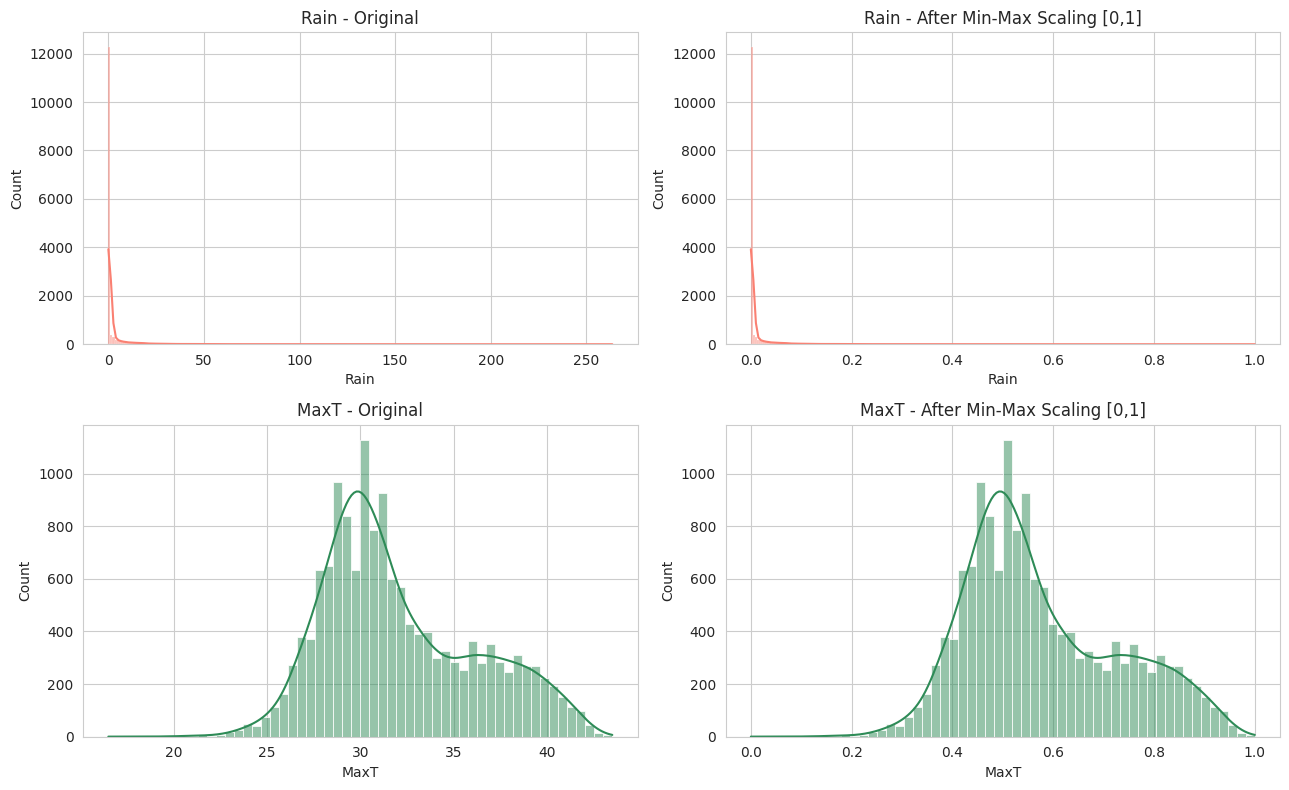

In [10]:
# Visualize effect of Min-Max scaling on a skewed column (Rain) vs a symmetric column (MaxT)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df['Rain'], kde=True, ax=axes[0,0], color='salmon')
axes[0,0].set_title('Rain - Original')

sns.histplot(df_sklearn_scaled['Rain'], kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Rain - After Min-Max Scaling [0,1]')

sns.histplot(df['MaxT'], kde=True, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('MaxT - Original')

sns.histplot(df_sklearn_scaled['MaxT'], kde=True, ax=axes[1,1], color='seagreen')
axes[1,1].set_title('MaxT - After Min-Max Scaling [0,1]')

plt.tight_layout()
plt.show()


**Inference:** Min-Max scaling changes the **axis range** (from original units to [0, 1]) but **preserves the exact shape/skewness** of the distribution — `Rain` is still heavily right-skewed after scaling, and `MaxT` is still roughly symmetric. This is expected: Min-Max scaling is a *linear* transformation, so it normalizes **scale**, not **distribution shape**. If the goal were also to reduce skewness, a log-transform or Box-Cox/Yeo-Johnson transform would be needed in addition.

## 4. Label Encoding of the Ordinal Categorical Variable

`Rain_Intensity` has a **natural, meaningful order**: `Dry < Low < Moderate < Heavy`. For ordinal variables, **Label Encoding** (mapping categories to increasing integers) is appropriate because the numeric order itself carries information the model can use — unlike a nominal variable.

In [11]:
# Explicit ordinal mapping (preferred over blind LabelEncoder for ordinal data,
# since LabelEncoder alone sorts alphabetically and would NOT respect true rain-intensity order)
rain_order = {'Dry': 0, 'Low': 1, 'Moderate': 2, 'Heavy': 3}
df['Rain_Intensity_Encoded'] = df['Rain_Intensity'].map(rain_order)

# Cross-check using Scikit-Learn's LabelEncoder on the same category set (for demonstration)
le = LabelEncoder()
le.classes_ = np.array(['Dry', 'Low', 'Moderate', 'Heavy'])  # force the correct ordinal order
df['Rain_Intensity_Encoded_sklearn'] = le.transform(df['Rain_Intensity'])

df[['Rain', 'Rain_Intensity', 'Rain_Intensity_Encoded', 'Rain_Intensity_Encoded_sklearn']].drop_duplicates().sort_values('Rain_Intensity_Encoded').head(10)


,Rain,Rain_Intensity,Rain_Intensity_Encoded,Rain_Intensity_Encoded_sklearn
0,0.0,Dry,0,0
206,2.0,Low,1,1
208,0.4,Low,1,1
220,1.4,Low,1,1
7151,0.1,Low,1,1
262,1.5,Low,1,1
695,0.3,Low,1,1
362,0.9,Low,1,1
576,2.1,Low,1,1
657,2.4,Low,1,1


**Inference:** `Rain_Intensity` (`Dry, Low, Moderate, Heavy`) is now represented as integers `0, 1, 2, 3` respectively — exactly analogous to `Bachelor->0, Master->1, PhD->2`. Note we explicitly fixed the class order rather than relying on `LabelEncoder`'s default alphabetical sort, because alphabetical order (`Dry, Heavy, Low, Moderate`) would have **broken the true ordinal relationship**. This is an important, commonly-missed pitfall when label-encoding ordinal data.

## 5. One-Hot Encoding of the Nominal Categorical Variable

`Wind_Direction` (N, NE, E, SE, S, SW, W, NW) is **nominal** — there is no inherent order among compass directions, so assigning integers (as with Label Encoding) would wrongly imply a false ranking (e.g., that `SW` > `N`). Instead we use **One-Hot Encoding** via `pd.get_dummies()`.

We set `drop_first=True` to drop one dummy column, which prevents the **Dummy Variable Trap** — perfect multicollinearity that would occur if all *k* dummy columns were kept (since the *k*-th category is always fully predictable from the other *k-1* columns; e.g., "not N, not NE, ... not SW" always implies "W").

In [12]:
print("Unique Wind_Direction categories:", sorted(df['Wind_Direction'].unique()))

# One-Hot Encoding with drop_first=True to avoid the Dummy Variable Trap
wind_dummies = pd.get_dummies(df['Wind_Direction'], prefix='Wind', drop_first=True)
print(f"\nOriginal categories: 8  ->  One-hot columns created: {wind_dummies.shape[1]} (one dropped as reference category)")
wind_dummies.head()


Unique Wind_Direction categories: ['E', 'N', 'NE', 'NW', 'S', 'SE', 'SW', 'W']

Original categories: 8  ->  One-hot columns created: 7 (one dropped as reference category)


,Wind_N,Wind_NE,Wind_NW,Wind_S,Wind_SE,Wind_SW,Wind_W
0,False,False,False,False,False,False,True
1,False,False,False,False,True,False,False
2,False,False,False,True,False,False,False
3,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False


**Inference:** `pd.get_dummies(..., drop_first=True)` created **7 binary columns** instead of 8 for the 8 wind directions (the alphabetically-first category, `E`, is dropped and becomes the implicit **reference category** — represented when all 7 dummy columns are 0). This removes the redundant, perfectly-collinear column and avoids the Dummy Variable Trap, which would otherwise destabilize coefficient estimates in linear models (infinite variance / non-invertible design matrix).

## 6. Original vs. Transformed Dataset — Side-by-Side Comparison & Statistical Verification

We now assemble the final **transformed dataset**: Min-Max scaled numerical features + label-encoded ordinal feature + one-hot encoded nominal feature, and compare it against the original.

In [13]:
# Build final transformed dataset
df_transformed = pd.concat([
    df_sklearn_scaled,                              # Min-Max scaled numerical features [0,1]
    df[['Rain_Intensity_Encoded']].rename(columns={'Rain_Intensity_Encoded': 'Rain_Intensity'}),  # label encoded ordinal
    wind_dummies                                     # one-hot encoded nominal
], axis=1)

print("Original dataset shape:   ", df[num_cols + ['Rain_Intensity', 'Wind_Direction']].shape)
print("Transformed dataset shape:", df_transformed.shape)
df_transformed.head()


Original dataset shape:    (14853, 13)
Transformed dataset shape: (14853, 19)


,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Cum_Rain,Rain_Intensity,Wind_N,Wind_NE,Wind_NW,Wind_S,Wind_SE,Wind_SW,Wind_W
0,0.444444,0.371648,0.614458,0.263607,0.098566,0.0,0.814516,0.218274,0.640000,0.265152,0.0,0,False,False,False,False,False,False,True
1,0.455556,0.440613,0.746988,0.284952,0.111111,0.0,0.790323,0.243655,0.585455,0.265152,0.0,0,False,False,False,False,True,False,False
2,0.462963,0.383142,0.831325,0.327641,0.093190,0.0,0.733871,0.233503,0.527273,0.227273,0.0,0,False,False,False,True,False,False,False
3,0.462963,0.517241,0.867470,0.391676,0.123656,0.0,0.725806,0.213198,0.567273,0.257576,0.0,0,False,False,False,False,False,False,True
4,0.418519,0.478927,0.771084,0.434365,0.184588,0.0,0.717742,0.218274,0.549091,0.280303,0.0,0,False,False,False,False,False,False,False


In [14]:
print("=== ORIGINAL DATASET (selected columns) ===")
display(df[num_cols + ['Rain_Intensity', 'Wind_Direction']].head())

print("\n=== TRANSFORMED DATASET ===")
display(df_transformed.head())


=== ORIGINAL DATASET (selected columns) ===


,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Cum_Rain,Rain_Intensity,Wind_Direction
0,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,0.0,Dry,W
1,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,0.0,Dry,SE
2,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,0.0,Dry,S
3,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,0.0,Dry,W
4,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,0.0,Dry,E



=== TRANSFORMED DATASET ===


,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Cum_Rain,Rain_Intensity,Wind_N,Wind_NE,Wind_NW,Wind_S,Wind_SE,Wind_SW,Wind_W
0,0.444444,0.371648,0.614458,0.263607,0.098566,0.0,0.814516,0.218274,0.640000,0.265152,0.0,0,False,False,False,False,False,False,True
1,0.455556,0.440613,0.746988,0.284952,0.111111,0.0,0.790323,0.243655,0.585455,0.265152,0.0,0,False,False,False,False,True,False,False
2,0.462963,0.383142,0.831325,0.327641,0.093190,0.0,0.733871,0.233503,0.527273,0.227273,0.0,0,False,False,False,True,False,False,False
3,0.462963,0.517241,0.867470,0.391676,0.123656,0.0,0.725806,0.213198,0.567273,0.257576,0.0,0,False,False,False,False,False,False,True
4,0.418519,0.478927,0.771084,0.434365,0.184588,0.0,0.717742,0.218274,0.549091,0.280303,0.0,0,False,False,False,False,False,False,False


In [15]:
# Side-by-side original vs transformed stats for numerical (Min-Max) features
compare_stats = pd.DataFrame({
    'Original_min': df[num_cols].min(),
    'Original_max': df[num_cols].max(),
    'Original_mean': df[num_cols].mean(),
    'Scaled_min': df_sklearn_scaled[num_cols].min(),
    'Scaled_max': df_sklearn_scaled[num_cols].max(),
    'Scaled_mean': df_sklearn_scaled[num_cols].mean(),
})
compare_stats


,Original_min,Original_max,Original_mean,Scaled_min,Scaled_max,Scaled_mean
MaxT,16.5,43.5,32.055807,0.0,1.0,0.576141
MinT,4.5,30.6,19.568720,0.0,1.0,0.577346
RH1,17.0,100.0,81.586481,0.0,1.0,0.778150
RH2,6.3,100.0,43.550549,0.0,1.0,0.397551
Wind,0.2,56.0,8.692278,0.0,1.0,0.152191
Rain,0.0,263.6,2.460378,0.0,1.0,0.009334
SSH,0.0,12.4,7.457052,0.0,1.0,0.601375
Evap,0.0,19.7,6.420043,0.0,1.0,0.325891
Radiation,0.8,28.3,17.877048,0.0,1.0,0.620984
FAO56_ET,0.4,13.6,4.808901,0.0,1.0,0.334008


**Verification — Min-Max scaled features:** for every numerical column, `Scaled_min = 0` and `Scaled_max = 1` exactly, confirming correct normalization. (`Scaled_mean` varies per column — it does **not** need to be 0.5, since mean is not preserved under min-max scaling unless the original distribution is symmetric within its own range.)

In [16]:
# Additionally demonstrate Standardization (mean=0, std=1) using StandardScaler,
# as requested for "standardized features" verification.
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
df_standardized = pd.DataFrame(std_scaler.fit_transform(df[num_cols]), columns=num_cols, index=df.index)

std_check = pd.DataFrame({
    'Standardized_mean': df_standardized.mean().round(10),
    'Standardized_std': df_standardized.std(ddof=0).round(10)
})
std_check


,Standardized_mean,Standardized_std
MaxT,-0.0,1.0
MinT,0.0,1.0
RH1,-0.0,1.0
RH2,-0.0,1.0
Wind,0.0,1.0
Rain,0.0,1.0
SSH,0.0,1.0
Evap,0.0,1.0
Radiation,0.0,1.0
FAO56_ET,0.0,1.0


**Verification — Standardized features:** every column now has **mean ≈ 0** and **standard deviation ≈ 1** (tiny deviations are floating-point rounding, not real error), confirming `StandardScaler` worked correctly.

In [17]:
# Verify Min-Max scaled features precisely
mm_check = pd.DataFrame({
    'MinMax_min': df_sklearn_scaled.min().round(10),
    'MinMax_max': df_sklearn_scaled.max().round(10)
})
mm_check


,MinMax_min,MinMax_max
MaxT,0.0,1.0
MinT,0.0,1.0
RH1,0.0,1.0
RH2,0.0,1.0
Wind,0.0,1.0
Rain,0.0,1.0
SSH,0.0,1.0
Evap,0.0,1.0
Radiation,0.0,1.0
FAO56_ET,0.0,1.0


In [18]:
# Verify one-hot encoded columns are proper binary indicators, and that dropping one column avoided the trap
print("Unique values across one-hot columns:", np.unique(wind_dummies.values))
print("\nSum of all 7 one-hot columns for a few rows (should be 0 or 1, never >1):")
print(wind_dummies.sum(axis=1).value_counts())

print("\nRow where all 7 dummies are 0 -> implies reference category 'E':")
ref_rows = wind_dummies[wind_dummies.sum(axis=1) == 0]
print("Number of rows encoded as reference category 'E':", len(ref_rows))
print("Actual Wind_Direction value for these rows (should all be 'E'):", df.loc[ref_rows.index, 'Wind_Direction'].unique())


Unique values across one-hot columns: [False  True]

Sum of all 7 one-hot columns for a few rows (should be 0 or 1, never >1):
1    13045
0     1808
Name: count, dtype: int64

Row where all 7 dummies are 0 -> implies reference category 'E':
Number of rows encoded as reference category 'E': 1808
Actual Wind_Direction value for these rows (should all be 'E'): <StringArray>
['E']
Length: 1, dtype: str


**Inference:** Each one-hot column contains only `0`/`1`, and the row-sum is always either 0 (reference category `E`) or 1 (one of the other 7 directions) — never more than 1, confirming mutually-exclusive, correctly-formed dummy variables with no redundant column (Dummy Variable Trap avoided).

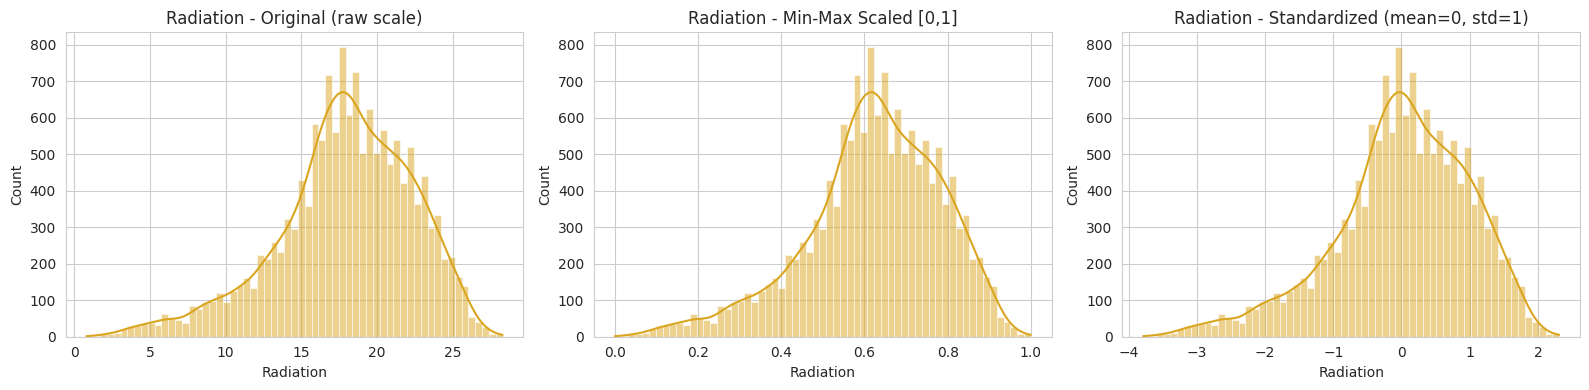

In [19]:
# Final side-by-side visual: distribution before vs after for one representative column
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['Radiation'], kde=True, ax=axes[0], color='goldenrod')
axes[0].set_title('Radiation - Original (raw scale)')

sns.histplot(df_sklearn_scaled['Radiation'], kde=True, ax=axes[1], color='goldenrod')
axes[1].set_title('Radiation - Min-Max Scaled [0,1]')

sns.histplot(df_standardized['Radiation'], kde=True, ax=axes[2], color='goldenrod')
axes[2].set_title('Radiation - Standardized (mean=0, std=1)')

plt.tight_layout()
plt.show()


## Overall Summary & Inferences

1. **Dataset:** ICRISAT daily weather data (14,853 rows × 16 columns), a realistic multi-attribute dataset mixing numerical (temperature, humidity, wind, rainfall, sunshine, evaporation, radiation, ET) and categorical (`Wind_Direction`, engineered `Rain_Intensity`) features — directly usable for AI use cases like **evapotranspiration/crop-water-demand prediction**.
2. **Skewness:** Rainfall-based columns (`Rain`, `Cum_Rain`) are heavily right-skewed; temperature/humidity/radiation columns are fairly symmetric. This informs whether a log-transform is needed before modeling in addition to scaling.
3. **Min-Max Scaling:** The manual NumPy/Pandas formula and Scikit-Learn's `MinMaxScaler` produce **identical** results (verified to ~0 difference), each correctly bounding all numerical features to **[0, 1]**. Scaling changes range, not shape/skewness.
4. **Label Encoding** was correctly applied to the **ordinal** `Rain_Intensity` feature (`Dry<Low<Moderate<Heavy` → `0,1,2,3`), preserving its true order — critical because naive alphabetical `LabelEncoder` would have scrambled that order.
5. **One-Hot Encoding** (`pd.get_dummies(drop_first=True)`) was correctly applied to the **nominal** `Wind_Direction` feature, producing 7 (not 8) binary columns and avoiding the **Dummy Variable Trap** / multicollinearity.
6. **Verification:** Min-Max scaled columns confirmed min=0/max=1 for every feature; a companion `StandardScaler` pass confirmed mean≈0/std≈1 for every feature — both matching the expected statistical properties exactly.

**Takeaway:** Choosing the *right* encoding (label vs. one-hot) based on whether a categorical variable is *ordinal* vs *nominal*, and the right scaling (min-max vs standardization) based on the downstream model's assumptions, is essential preprocessing before this weather dataset can be used to train reliable AI/ML models.